# Data Preprocessing and Preliminary Plotting

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from astropy.time import Time

### Importing the data
- shape (N, 2)
- 2 -> (BJD, S-index)

In [6]:
data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()

C:\Users\Joey\AppData\Local\Temp\ipykernel_78760\674720250.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()


In [16]:
print(data.shape)
print(data[0])
time0 = data[1200,0]
print(time0)
t = Time(data[:,0], format="jd", scale='tdb')
print(f"Start in {t[0].jyear} = {t[0].jd}")
print(t.jd)
jd_0 = t[0].jd
jd = t.jd - jd_0
print(jd)

(1395, 2)
[2.4391948e+06 1.7560000e-01]
2449359.93213
Start in 1966.1869952087607 = 2439194.8
[2439194.8     2439486.8     2439515.8     ... 2449819.73779 2449819.73877
 2449819.74023]
[    0.        292.        321.      ... 10624.93779 10624.93877
 10624.94023]


### Preliminary plotting

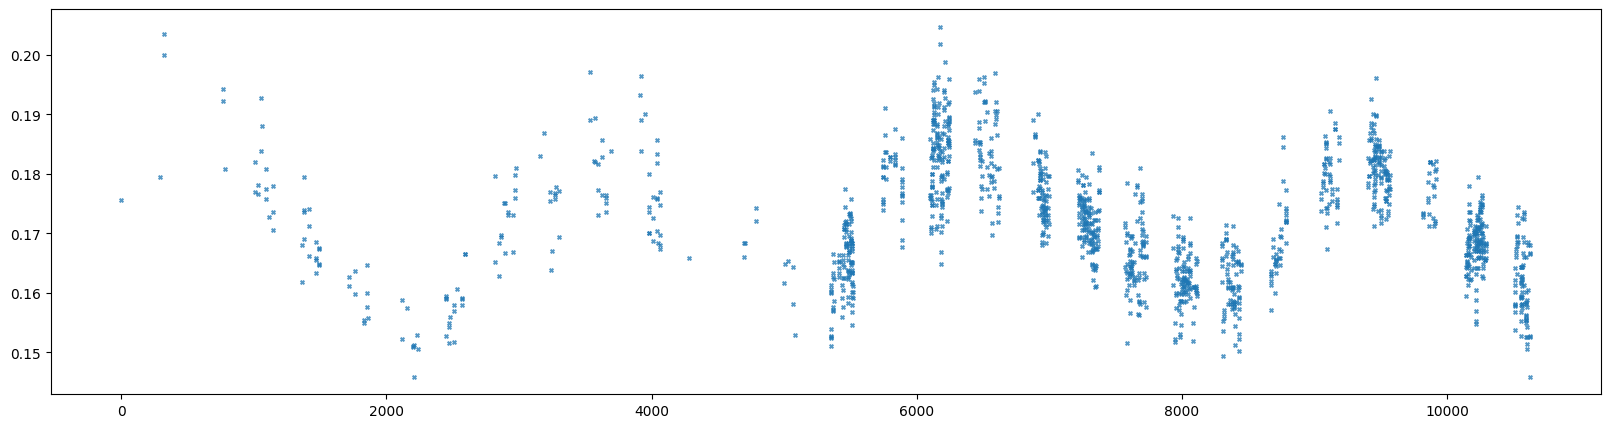

In [17]:
fig = plt.figure(figsize=(20,5))
plt.scatter(jd, data[:,1], marker='x', s=7, alpha=0.75)
plt.show()

### Split train/valid/test in chronological order
- Let's split this 70/15/15 by datapoint number

In [6]:
dataset_length = len(data)
train_split = 0.7
valid_split = 0.15
# test_split = 1 - train_split - valid_split

train_idx = round(train_split*dataset_length)
valid_idx = round((valid_split + train_split) * dataset_length)

trainset = data[:train_idx]
validset = data[train_idx:valid_idx]
testset = data[valid_idx:]

print(trainset.shape, validset.shape, testset.shape)
print(1183 + 253+ 254)

(4444, 2) (953, 2) (952, 2)
1690


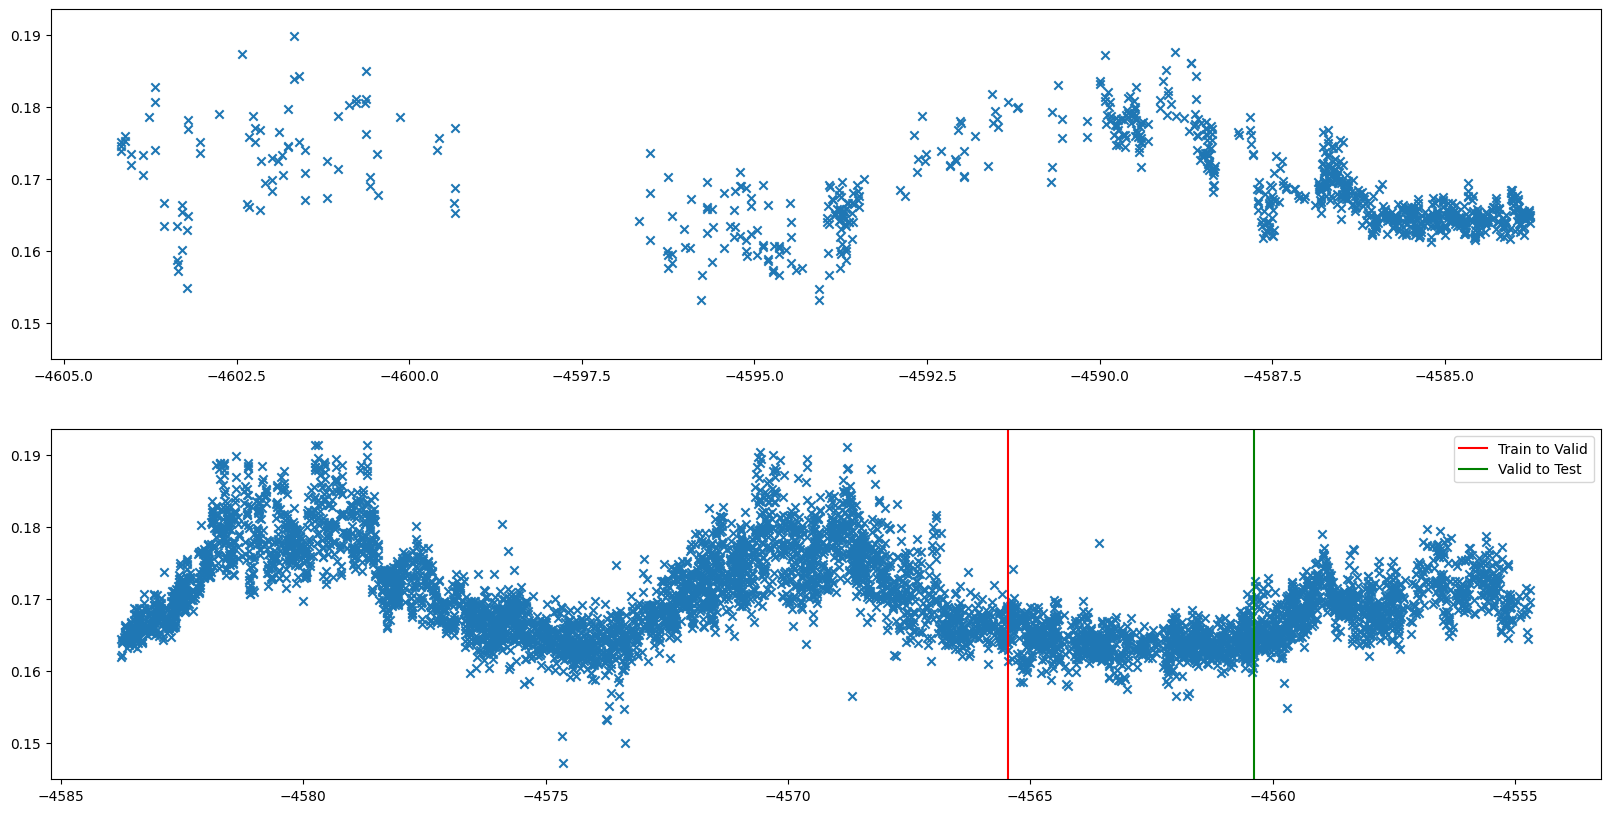

In [7]:
lim = 1690 //2
fig, ax = plt.subplots(2,1,figsize=(20,10), sharey =  True)
ax[0].scatter(t.jyear[:lim], data[:lim,1], marker="x")
ax[1].scatter(t.jyear[lim:], data[lim:,1], marker='x')
plt.axvline(t.jyear[train_idx], label = "Train to Valid", color = "red")
plt.axvline(t.jyear[valid_idx], label = "Valid to Test", color = "green")
plt.legend()
plt.show()

In [8]:
t.jyear[-1]

np.float64(-4554.689544147845)

In [9]:
t.jyear[0]

np.float64(-4604.172876112252)